In [2]:
import numpy as np
import pandas as pd
import streamlit as st
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import joblib
import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")



In [3]:
diabetes_dataset = pd.read_csv('diabetes.csv')
diabetes_dataset.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
diabetes_dataset.shape


(768, 9)

In [5]:
diabetes_dataset.describe()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [6]:
diabetes_dataset['Outcome'].value_counts()


Outcome
0    500
1    268
Name: count, dtype: int64

In [7]:
diabetes_dataset.groupby('Outcome').mean()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Outcome,,,,,,,,
0,3.298000,109.980000,68.184000,19.664000,68.792000,30.304200,0.429734,31.190000
1,4.865672,141.257463,70.824627,22.164179,100.335821,35.142537,0.550500,37.067164


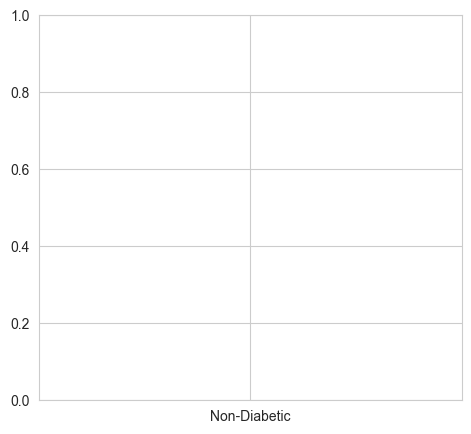

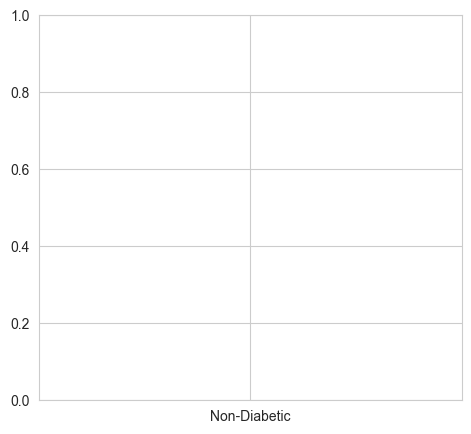

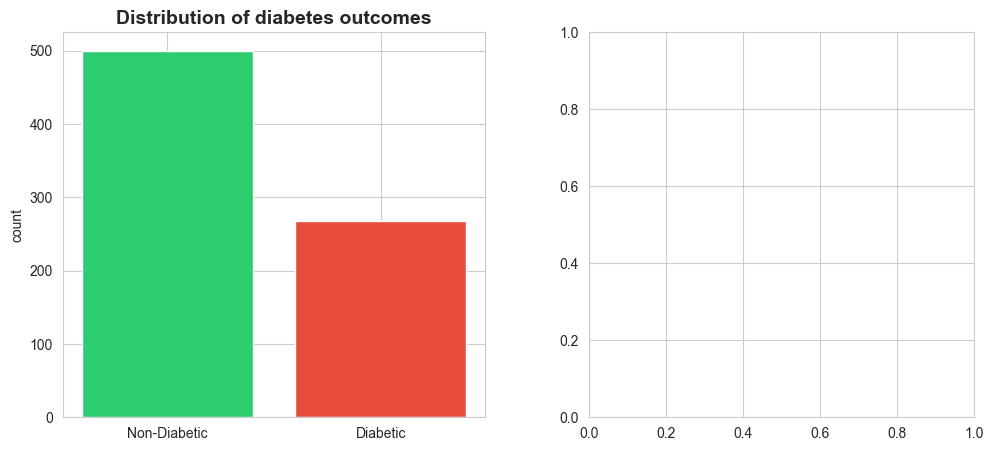

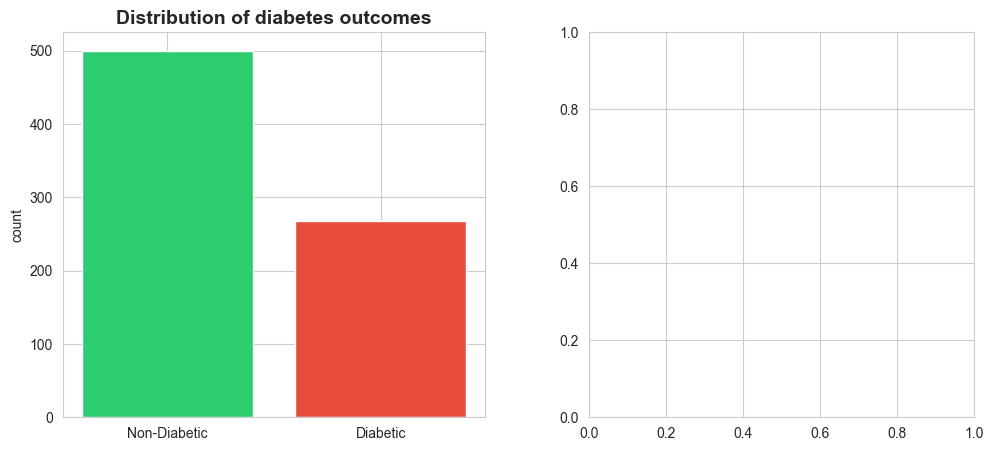

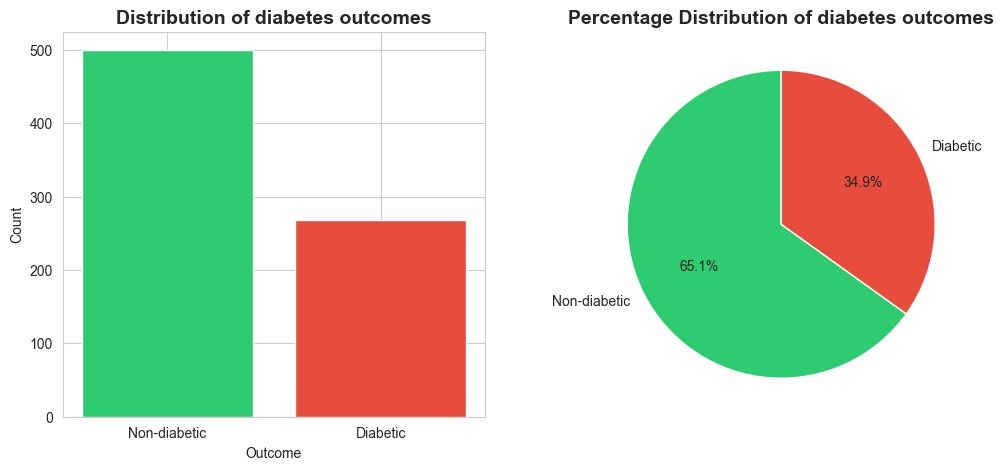

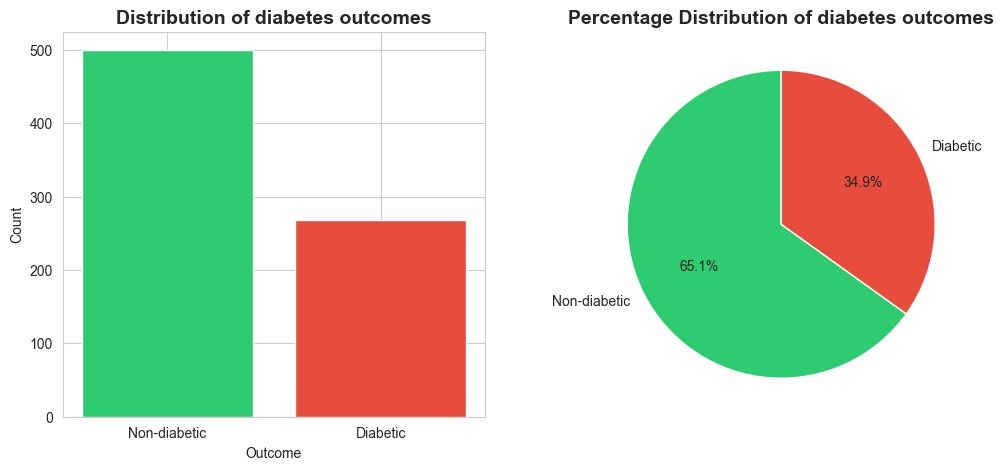

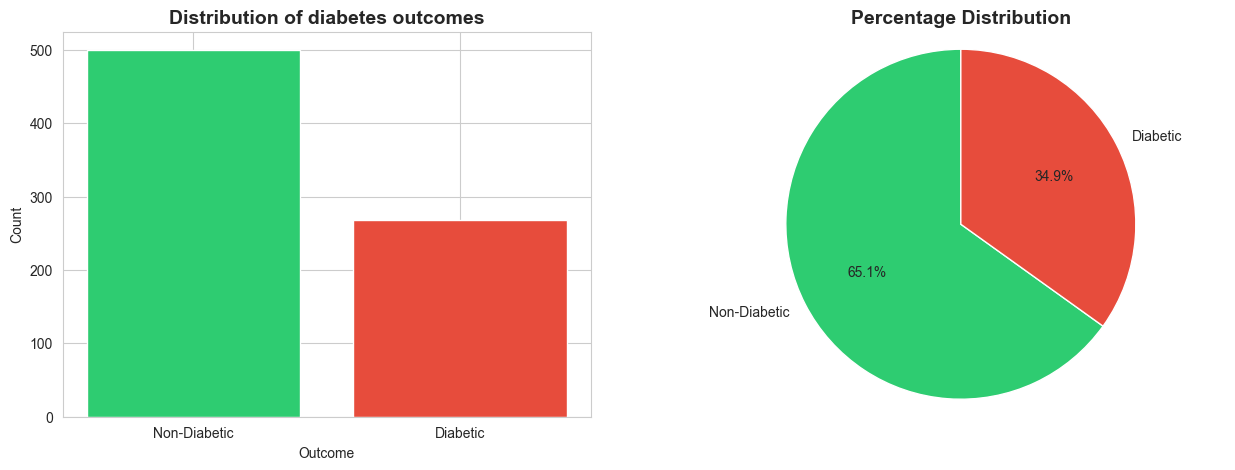

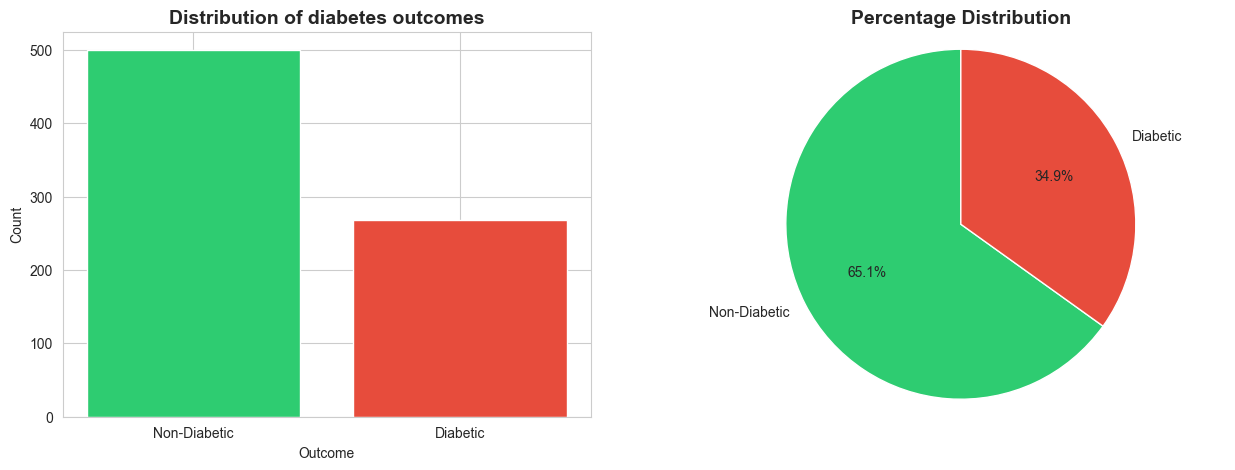

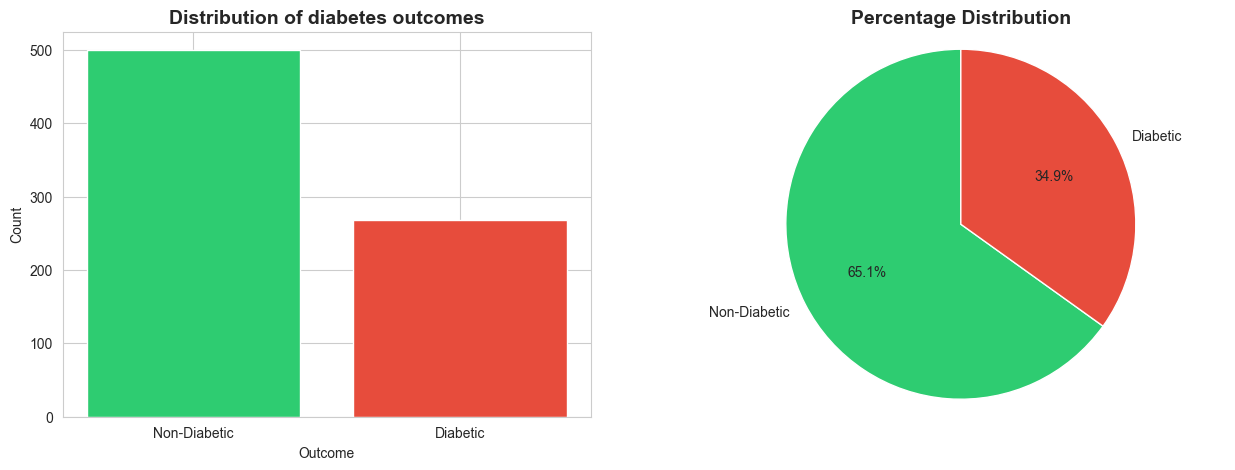

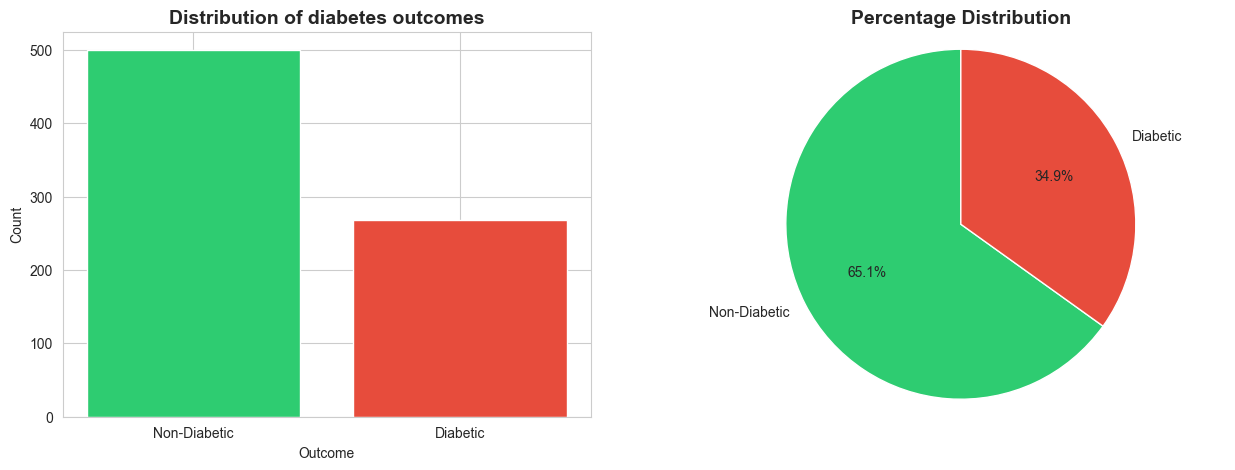

In [22]:
# Count values
%matplotlib inline
outcome_counts = diabetes_dataset['Outcome'].value_counts().sort_index()

plt.figure(figsize=(15,5))  # just wider like the video

# ---- Bar Chart ----
plt.subplot(1,2,1)
plt.bar(['Non-Diabetic', 'Diabetic'], outcome_counts.values,
        color=['#2ecc71', '#e74c3c'])  # your same colors
plt.xlabel('Outcome')
plt.ylabel('Count')
plt.title('Distribution of diabetes outcomes', fontsize=14, fontweight='bold')

# ---- Pie Chart ----
plt.subplot(1,2,2)
plt.pie(outcome_counts.values,
        labels=['Non-Diabetic', 'Diabetic'],
        colors=['#2ecc71', '#e74c3c'],
        autopct='%1.1f%%',
        startangle=90)
plt.title('Percentage Distribution', fontsize=14, fontweight='bold')
plt.axis('equal')

plt.show()

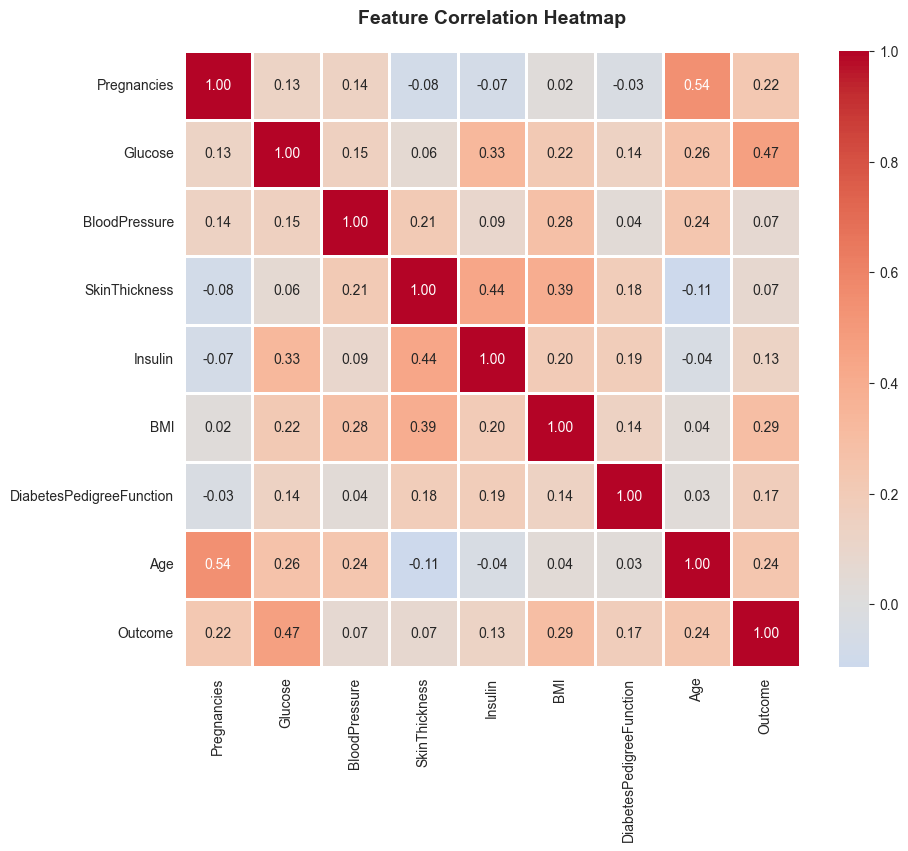

In [31]:
plt.figure(figsize=(10,8))
correlation = diabetes_dataset.corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0 , square= True, linewidths=1, fmt='.2f' )
plt.title('Feature Correlation Heatmap', fontsize=14, pad=20, fontweight='bold')
plt.show()

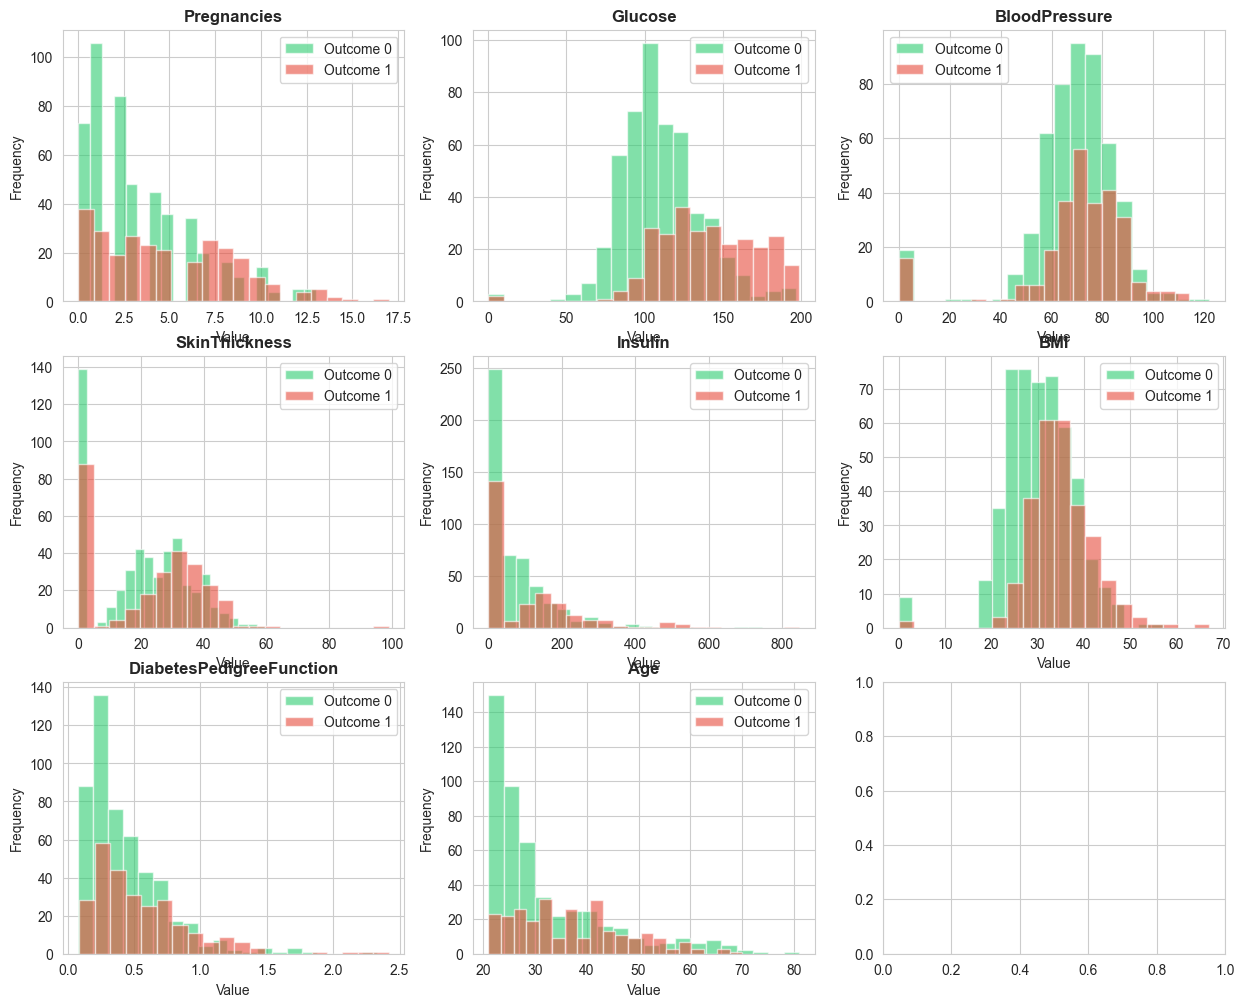

In [33]:
fig, axes = plt.subplots(3,3,figsize=(15,12))
features = diabetes_dataset.columns[:-1]

for idx, feature in enumerate (features):

    row, col = idx //3, idx % 3

    for outcome in [0,1]:

        data = diabetes_dataset[diabetes_dataset['Outcome'] == outcome][feature] 
        axes[row,col].hist(data, alpha=0.6, bins=20, label =f'Outcome {outcome}',
                           color=['#2ecc71', '#e74c3c'][outcome])
        axes[row,col].set_title(feature, fontweight='bold')
        axes[row, col].set_xlabel('Value')
        axes[row, col].set_ylabel('Frequency')
        axes[row,col].legend()
plt.show() 

In [34]:
X = diabetes_dataset.drop(columns='Outcome',axis=1)
Y = diabetes_dataset['Outcome']

print(X)
print(Y)


     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  
0                       0.627   50  
1                       0.351   31  


In [35]:
scaler = StandardScaler()
X = scaler.fit_transform(X)
X


array([[ 0.63994726,  0.84832379,  0.14964075, ...,  0.20401277,
         0.46849198,  1.4259954 ],
       [-0.84488505, -1.12339636, -0.16054575, ..., -0.68442195,
        -0.36506078, -0.19067191],
       [ 1.23388019,  1.94372388, -0.26394125, ..., -1.10325546,
         0.60439732, -0.10558415],
       ...,
       [ 0.3429808 ,  0.00330087,  0.14964075, ..., -0.73518964,
        -0.68519336, -0.27575966],
       [-0.84488505,  0.1597866 , -0.47073225, ..., -0.24020459,
        -0.37110101,  1.17073215],
       [-0.84488505, -0.8730192 ,  0.04624525, ..., -0.20212881,
        -0.47378505, -0.87137393]], shape=(768, 8))

In [36]:
x_train, x_test, y_train , y_test = train_test_split(X,Y,test_size=0.2 ,stratify=Y, random_state=2)

print(X.shape, x_train.shape, x_test.shape)


(768, 8) (614, 8) (154, 8)


In [37]:
classifier = svm.SVC(kernel='linear', probability=True)
classifier.fit(x_train, y_train)


,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [38]:
x_train_prediction = classifier.predict(x_train)
training_data_accuracy = accuracy_score(x_train_prediction, y_train)
training_data_accuracy

0.7866449511400652

In [39]:
x_test_prediction = classifier.predict(x_test)
test_data_accuracy = accuracy_score(x_test_prediction, y_test)
test_data_accuracy


0.7727272727272727

In [40]:
precision = precision_score(y_test, x_test_prediction)
recall = recall_score(y_test, x_test_prediction)
f1 = f1_score(y_test, x_test_prediction)

print(precision, recall, f1)

0.7567567567567568 0.5185185185185185 0.6153846153846154


In [41]:
cm_svm = confusion_matrix(y_test, x_test_prediction)
cm_svm

array([[91,  9],
       [26, 28]])

<function matplotlib.pyplot.xlabel(xlabel: 'str', fontdict: 'dict[str, Any] | None' = None, labelpad: 'float | None' = None, *, loc: "Literal['left', 'center', 'right'] | None" = None, **kwargs) -> 'Text'>

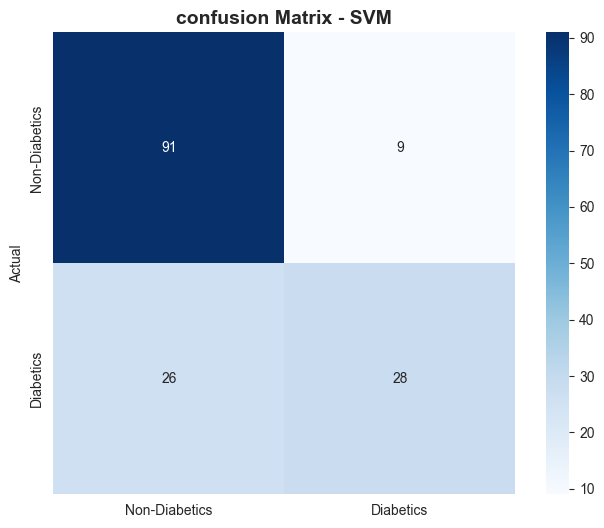

In [42]:
plt.figure(figsize=(8,6))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', square= True,
            xticklabels=['Non-Diabetics', 'Diabetics'],
            yticklabels=['Non-Diabetics', 'Diabetics'])
plt.title('confusion Matrix - SVM', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel


In [43]:
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=2)
rf_classifier.fit(x_train, y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [44]:
x_train_prediction_rf = rf_classifier.predict(x_train)


In [46]:
training_data_accuracy_rf = accuracy_score(x_train_prediction_rf, y_train)
training_data_accuracy_rf

1.0

In [47]:
x_test_prediction_rf = rf_classifier.predict(x_test)
test_data_accuracy_rf = accuracy_score(x_test_prediction_rf, y_test)


In [48]:
test_data_accuracy_rf

0.7272727272727273

In [49]:
precision_rf = precision_score(y_test, x_test_prediction_rf)


In [50]:
recall_rf = recall_score(y_test, x_test_prediction_rf)


In [52]:
f1_rf = f1_score(y_test, x_test_prediction_rf)

In [53]:
print(precision_rf, recall_rf, f1_rf)

0.65 0.48148148148148145 0.5531914893617021


In [54]:
cm_rf = confusion_matrix(y_test, x_test_prediction_rf)
print(cm_rf)

[[86 14]
 [28 26]]


Text(0.5, 1.0, 'Confusion Matrix - random forest')

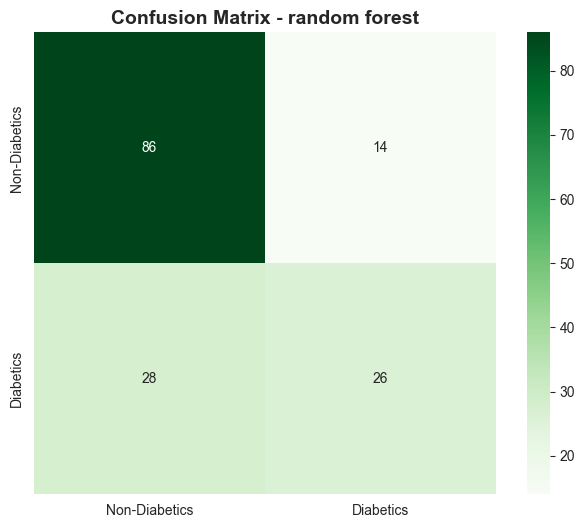

In [55]:
plt.figure(figsize=(8,6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap="Greens", square=True, 
            xticklabels=['Non-Diabetics', 'Diabetics'],
            yticklabels=['Non-Diabetics','Diabetics'])
plt.title('Confusion Matrix - random forest', fontsize=14, fontweight='bold')

In [57]:
print('SVM', test_data_accuracy)
print('Random Forest', test_data_accuracy_rf)

SVM 0.7727272727272727
Random Forest 0.7272727272727273


In [58]:
joblib.dump(classifier, 'diabetes_model.pkl')

['diabetes_model.pkl']

In [61]:
input_data = (5,166,72,19,175,25.8,0.587,51)
input_num_array = np.asarray(input_data)
reshape = input_num_array.reshape(1,-1)

std_data = scaler.transform(reshape)
prediction = classifier.predict(std_data)

In [62]:
prediction

array([1])

In [63]:
import joblib

joblib.dump(classifier, "diabetes_model.pkl")
joblib.dump(scaler, "scaler_svm.pkl")

print("Model and scaler saved successfully!")


Model and scaler saved successfully!
